In [1]:
import requests
import os
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import datetime
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
number_of_lags=20
bollinger_days=40

In [54]:
def calculate_rsi(prices, period=20):
    """Calculate Relative Strength Index (RSI)"""
    deltas = np.diff(prices)
    gains = np.where(deltas > 0, deltas, 0)
    losses = np.where(deltas < 0, -deltas, 0)
    
    avg_gain = np.convolve(gains, np.ones(period)/period, mode='valid')
    avg_loss = np.convolve(losses, np.ones(period)/period, mode='valid')
    
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    
    return np.concatenate(([np.nan] * (len(prices) - len(rsi)), rsi))


In [55]:
def stochastic_oscillator(prices, period=20):
    """Calculate Stochastic Oscillator %K and %D"""
    high_n = np.array([np.max(prices[i-period+1:i+1]) for i in range(period-1, len(prices))])
    low_n = np.array([np.min(prices[i-period+1:i+1]) for i in range(period-1, len(prices))])
    
    k = 100 * (prices[period-1:] - low_n) / (high_n - low_n)
    d = np.convolve(k, np.ones(3)/3, mode='valid')

    k = np.concatenate(([np.nan] * (period-1), k))
    d = np.concatenate(([np.nan] * (period-1 + 2), d))  # Aligning with %K

    return k, d

In [56]:
def calculate_momentum(prices, period=10):
    """Calculate momentum as the difference between current price and price x days ago."""
    momentum = prices - np.roll(prices, period)
    momentum[:period] = np.nan  # Set first 'period' values to NaN
    return momentum

In [71]:
def weighted_moving_average(prices, period=20, step=1):
    """Calculate Weighted Moving Average (WMA) where recent points get higher weight."""
    weights = np.arange(1, period + 1, step=step)  # Assign weights (1, 2, 3, ..., period)
    wma = np.convolve(prices, weights / weights.sum(), mode='valid')
    
    # Align the result with original length by padding with NaN
    return np.concatenate(([np.nan] * (len(prices) - len(wma)), wma))

In [77]:
def bollinger_bands(prices, period=20, std_dev_factor=2):
    """Calculate Bollinger Bands."""
    sma = np.convolve(prices, np.ones(period)/period, mode='valid')  # Simple Moving Average
    rolling_std = np.array([np.std(prices[i-period+1:i+1]) for i in range(period-1, len(prices))])  # Rolling Std Dev

    upper_band = sma + std_dev_factor * rolling_std
    lower_band = sma - std_dev_factor * rolling_std

    # Align lengths with original price data by padding with NaN
    upper_band = np.concatenate(([np.nan] * (len(prices) - len(upper_band)), upper_band))
    lower_band = np.concatenate(([np.nan] * (len(prices) - len(lower_band)), lower_band))
    sma = np.concatenate(([np.nan] * (len(prices) - len(sma)), sma))

    return sma, upper_band, lower_band


In [83]:
def momentum(prices, window=10):
    """Calculate momentum as the sum of differences over a rolling window."""
    diffs = np.diff(prices)  # First-order differences
    momentum_values = np.convolve(diffs, np.ones(window), mode='valid')  # Sum over window

    # Align lengths by padding with NaN
    momentum_values = np.concatenate(([np.nan] * (len(prices) - len(momentum_values)), momentum_values))
    return momentum_values


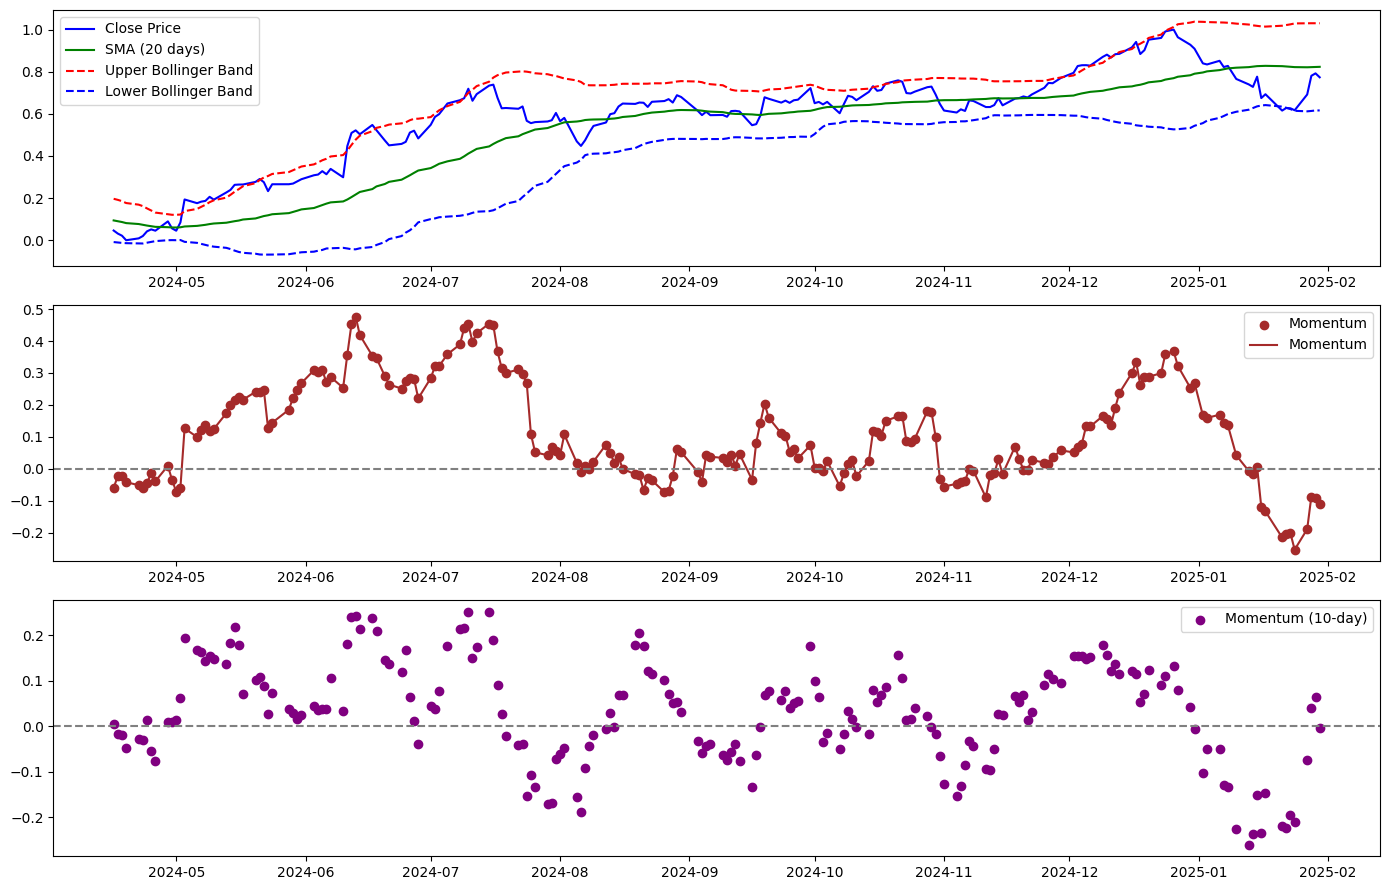

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Stock,RSI,Stochastic_K,...,Close_Lag10,Close_Lag11,Close_Lag12,Close_Lag13,Close_Lag14,Close_Lag15,Close_Lag16,Close_Lag17,Close_Lag18,Close_Lag19
Date,,,,,,,,,,,,,,,,,,,,,
2024-04-16 00:00:00-04:00,171.130799,173.133547,167.663349,0.046126,73711200,0.0,0.0,AAPL,51.195790,7.480650,...,0.040439,0.052971,0.068241,0.087513,0.049601,0.061607,0.076666,0.067083,0.143960,0.116684
2024-04-17 00:00:00-04:00,168.998498,170.034742,167.394302,0.031593,50901200,0.0,0.0,AAPL,46.436302,1.028518,...,0.048969,0.040439,0.052971,0.068241,0.087513,0.049601,0.061607,0.076666,0.067083,0.143960
2024-04-18 00:00:00-04:00,167.424180,168.031982,165.949521,0.021483,43122900,0.0,0.0,AAPL,46.176930,0.000000,...,0.040229,0.048969,0.040439,0.052971,0.068241,0.087513,0.049601,0.061607,0.076666,0.067083
2024-04-19 00:00:00-04:00,165.610765,165.800067,163.488440,0.000000,67772100,0.0,0.0,AAPL,40.675886,0.000000,...,0.048232,0.040229,0.048969,0.040439,0.052971,0.068241,0.087513,0.049601,0.061607,0.076666
2024-04-22 00:00:00-04:00,164.923258,166.656975,164.175962,0.008846,48116400,0.0,0.0,AAPL,44.622999,3.522028,...,0.036332,0.048232,0.040229,0.048969,0.040439,0.052971,0.068241,0.087513,0.049601,0.061607
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-24 00:00:00-05:00,224.779999,225.630005,221.410004,0.616974,54697900,0.0,0.0,AAPL,21.477664,0.384825,...,0.827511,0.822333,0.851820,0.834487,0.839666,0.909105,0.927918,0.963748,1.000000,0.991334
2025-01-27 00:00:00-05:00,224.020004,232.149994,223.979996,0.691803,94863400,0.0,0.0,AAPL,40.331945,19.846078,...,0.765682,0.827511,0.822333,0.851820,0.834487,0.839666,0.909105,0.927918,0.963748,1.000000
2025-01-28 00:00:00-05:00,230.850006,240.190002,230.809998,0.780584,75707600,0.0,0.0,AAPL,54.584325,42.935678,...,0.739787,0.765682,0.827511,0.822333,0.851820,0.834487,0.839666,0.909105,0.927918,0.963748


In [ ]:

def create_dataset(stock_symbol="AAPL"):
    stock = yf.Ticker(stock_symbol)
    df = stock.history(period="1y")
    df["Stock"] = stock_symbol
    scaler = MinMaxScaler(feature_range=(0,1))
    scaler.fit(df['Close'].to_numpy().reshape(-1,1))
    df['Close'] = scaler.transform(df['Close'].to_numpy().reshape(-1,1))

    # Compute indicators
    df['RSI'] = calculate_rsi(df['Close'].values, period=10)
    df['Stochastic_K'], df['Stochastic_D'] = stochastic_oscillator(df['Close'].values, period=50)
    df['Stochastic_difference'] = df['Stochastic_D'] - df['Stochastic_D'].shift(1)
    
    # Compute 20-day Moving Average
    df['Moving_Avg_10'] = df['Close'].rolling(window=10).mean()
    df['Moving_Avg_20'] = df['Close'].rolling(window=20).mean()
    df['Moving_Avg_30']=df['Close'].rolling(window=30).mean()
    df['Moving_Avg_50']=df['Close'].rolling(window=50).mean()
    df['Momentum'] = calculate_momentum(df['Close'].values, period=30)
    df['WMA_20'] = weighted_moving_average(df['Close'].values, period=40, step=5)
    df['SMA_20'], df['Upper_Band'], df['Lower_Band'] = bollinger_bands(df['Close'].values, period=40)
    df['Window_Momentum'] = momentum(df['Close'].values, window=10)

    for i in range(1, number_of_lags):
        df[f'Close_Lag{i}'] = df['Close'].shift(i)


    # Drop rows with NaN values
    df.dropna(inplace=True)

    # Plot the results
    plt.figure(figsize=(14,9))

    plt.subplot(3,1,1)
    plt.plot(df.index, df['Close'], label='Close Price', color='blue')
    # plt.plot(df.index, df['WMA_20'], label='Weighted MA (20 days)', color='purple')
    plt.plot(df.index, df['SMA_20'], label='SMA (20 days)', color='green')
    plt.plot(df.index, df['Upper_Band'], label='Upper Bollinger Band', color='red', linestyle='--')
    plt.plot(df.index, df['Lower_Band'], label='Lower Bollinger Band', color='blue', linestyle='--')
    # plt.plot(df.index, df['Moving_Avg_10'], label='10-day Moving Avg', color='red', linestyle='--')
    # plt.plot(df.index, df['Moving_Avg_20'], label='20-day Moving Avg', color='purple', linestyle='--')
    # plt.plot(df.index, df['Moving_Avg_30'], label='30-day Moving Avg', color='orange', linestyle='--')
    # plt.plot(df.index, df['Moving_Avg_50'], label='50-day Moving Avg', color='green', linestyle='--')
    plt.legend()

    plt.subplot(3,1,2)
    plt.scatter(df.index, df['Momentum'], label='Momentum', color='brown')
    plt.plot(df.index, df['Momentum'], label='Momentum', color='brown')
    plt.axhline(0, linestyle='--', color='gray')
    plt.legend()
    # plt.plot(df.index, df['RSI'], label='RSI', color='red')
    # plt.axhline(70, linestyle='--', color='gray')
    # plt.axhline(30, linestyle='--', color='gray')
    plt.legend()

    plt.subplot(3,1,3)
    # plt.plot(df.index, df['Stochastic_K'], label='%K', color='green')
    # plt.plot(df.index, df['Stochastic_D'], label='%D', color='orange')
    plt.scatter(df.index, df['Window_Momentum'], label='Momentum (10-day)', color='purple')
    
    plt.axhline(0, linestyle='--', color='gray')
    
    plt.legend()

    plt.tight_layout()
    plt.show()

    return df
create_dataset("AAPL")

In [23]:
# Define stock symbols
from sklearn.preprocessing import MinMaxScaler
stock_symbols = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]

# Fetch and combine stock data
dataframes = []
scalars=[]
for stock_symbol in stock_symbols:
    stock = yf.Ticker(stock_symbol)
    df = stock.history(period="1y")  # Fetch 1 year of historical data
    df["Stock"] = stock_symbol  # Add stock symbol column
    scaler= MinMaxScaler(feature_range=(0,1))
    scaler.fit_transform(df['Close'].to_numpy().reshape(-1,1))
    df['Close']=scaler.transform(df['Close'].to_numpy().reshape(-1,1))
    scalars.append(scaler)

    for i in range(1, 20):
      df[f'Close_Lag{i}'] = df['Close'].shift(i)

    # Drop rows with NaN values caused by shifting
    df.dropna(inplace=True)
    dataframes.append(df)

# Concatenate all stock data vertically
combined_data = pd.concat(dataframes).reset_index()




In [24]:
# One-hot encode the 'Stock' column
one_hot_encoded = pd.get_dummies(combined_data, columns=["Stock"])


one_hot_encoded.describe()
one_hot_encoded.info()
one_hot_encoded.to_csv('historical_data.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1165 entries, 0 to 1164
Data columns (total 32 columns):
 #   Column        Non-Null Count  Dtype                           
---  ------        --------------  -----                           
 0   Date          1165 non-null   datetime64[ns, America/New_York]
 1   Open          1165 non-null   float64                         
 2   High          1165 non-null   float64                         
 3   Low           1165 non-null   float64                         
 4   Close         1165 non-null   float64                         
 5   Volume        1165 non-null   int64                           
 6   Dividends     1165 non-null   float64                         
 7   Stock Splits  1165 non-null   float64                         
 8   Close_Lag1    1165 non-null   float64                         
 9   Close_Lag2    1165 non-null   float64                         
 10  Close_Lag3    1165 non-null   float64                         
 11  Clos

In [25]:
print(one_hot_encoded.describe())

              Open         High          Low        Close        Volume  \
count  1165.000000  1165.000000  1165.000000  1165.000000  1.165000e+03   
mean    248.835499   251.786745   245.791723     0.453879  4.686958e+07   
std     100.322675   101.255725    99.122049     0.246543  3.425817e+07   
min     131.403656   132.758744   130.198020     0.000000  7.164500e+06   
25%     176.563087   178.789993   174.300003     0.265885  2.277560e+07   
50%     201.020004   205.600006   198.779999     0.436786  3.654690e+07   
75%     263.299988   269.489990   257.630005     0.644255  6.041240e+07   
max     475.899994   488.540009   462.698189     1.000000  3.186799e+08   

         Dividends  Stock Splits   Close_Lag1   Close_Lag2   Close_Lag3  ...  \
count  1165.000000        1165.0  1165.000000  1165.000000  1165.000000  ...   
mean      0.003159           0.0     0.451170     0.448453     0.445815  ...   
std       0.042574           0.0     0.245719     0.244761     0.244347  ...   
min 